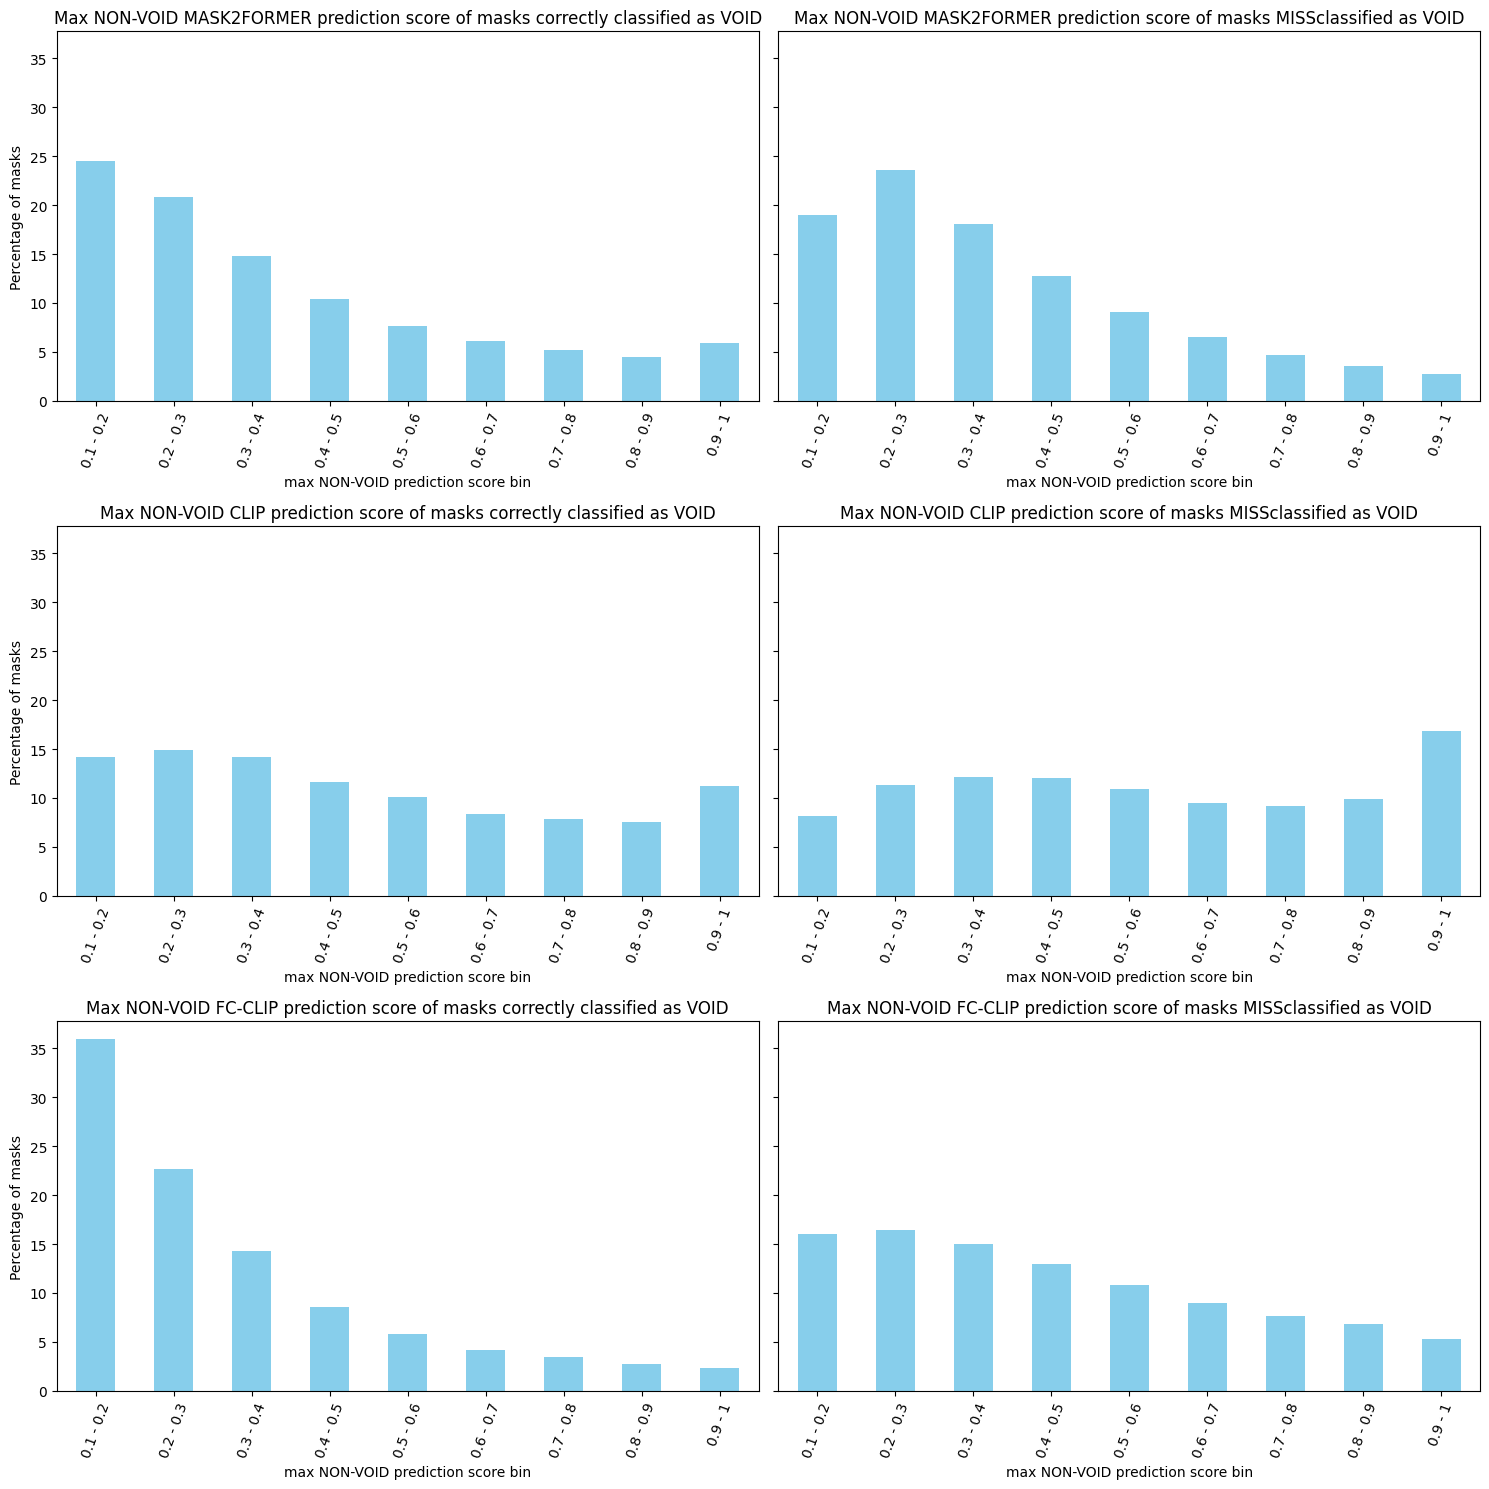

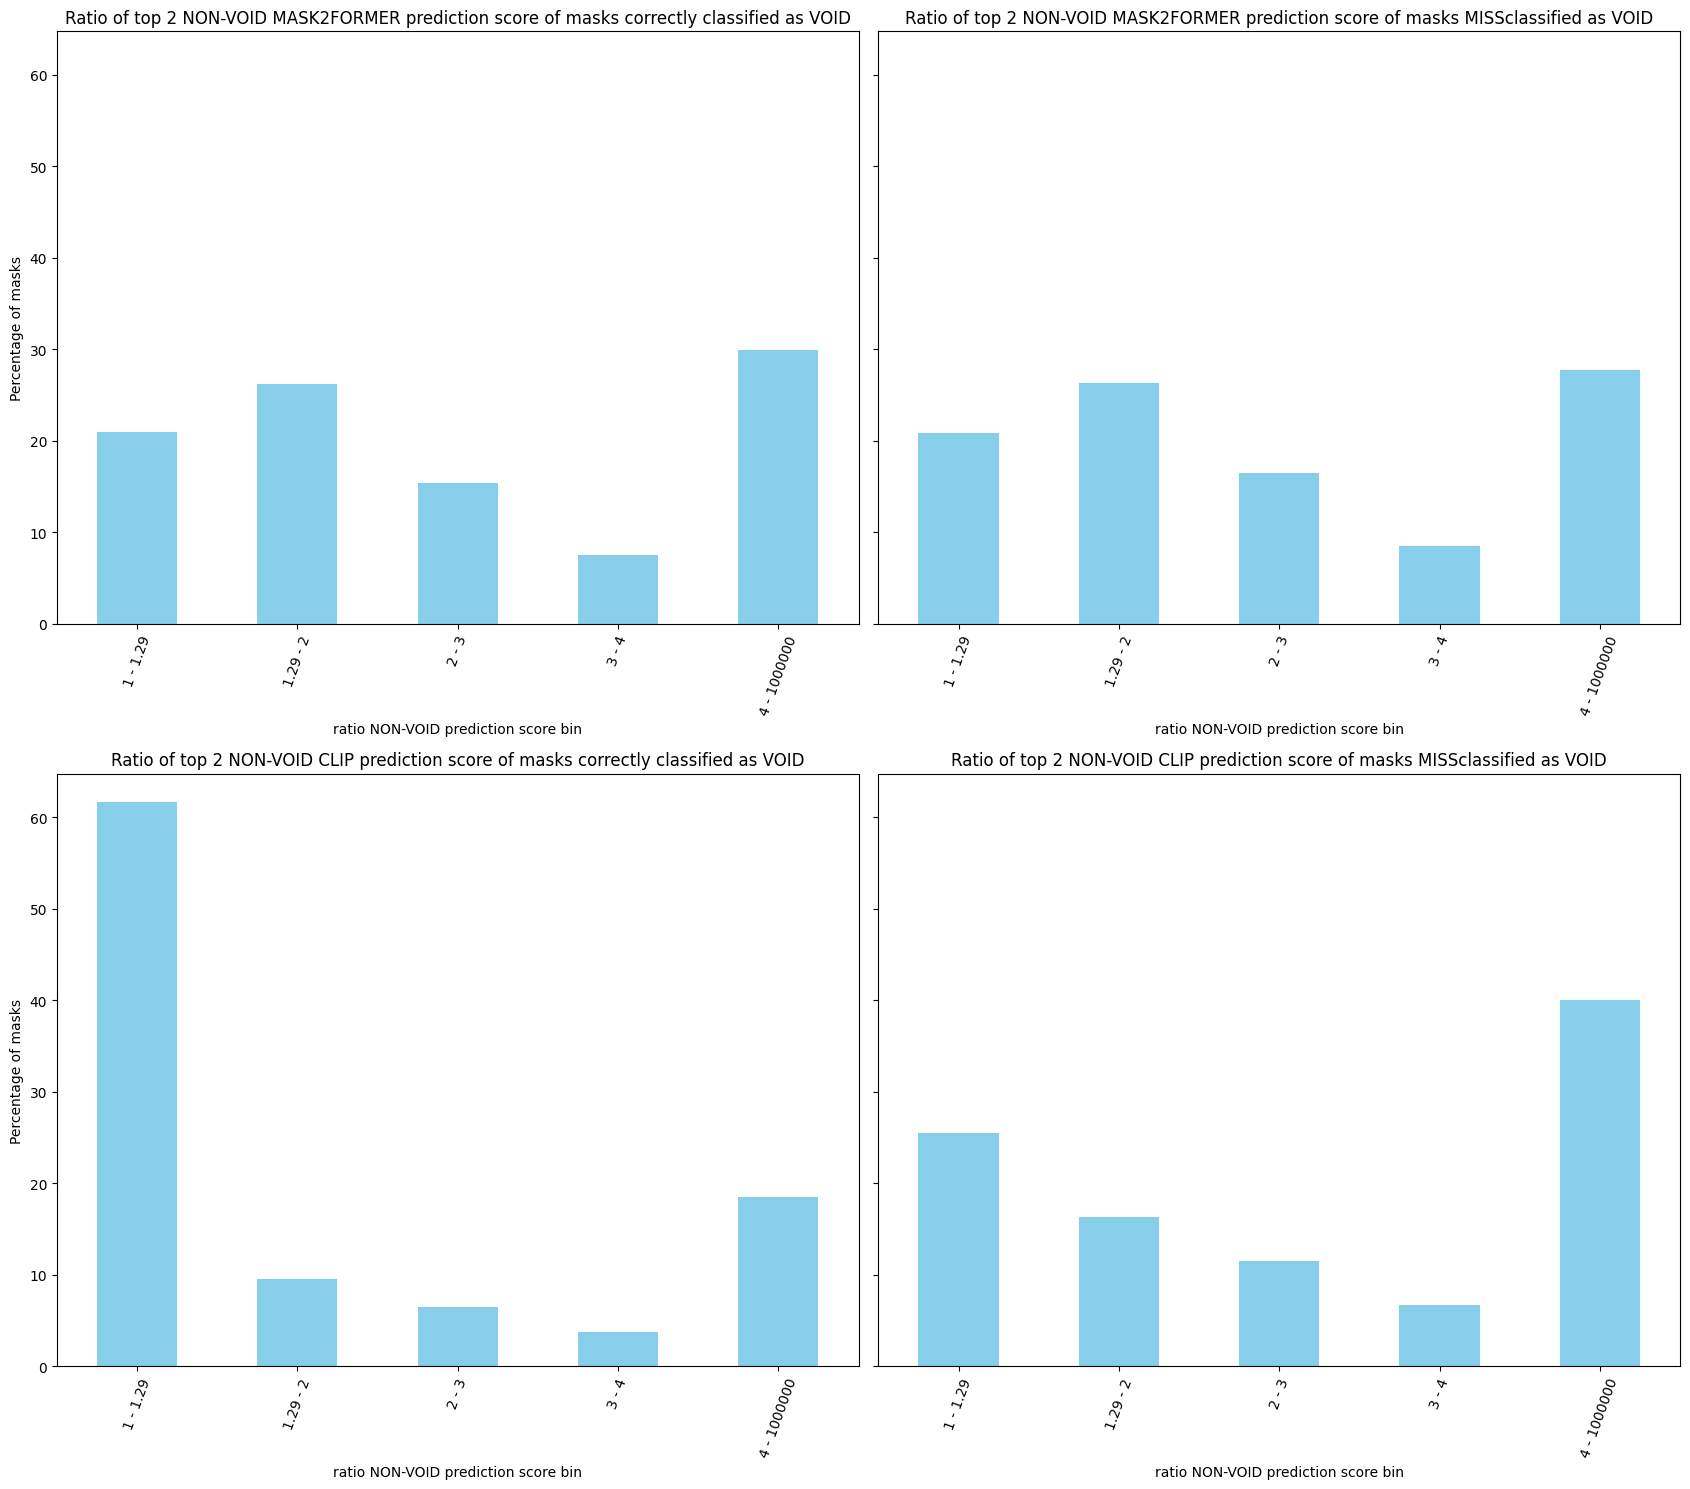

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('./void_histogram_data_2.csv')

mask2former_category_prob = 'mask2former_prob_1'
clip_category_prob = 'clip_prob_1'

# Contains also void probability so not really that good for plotting
pred_category_prob = 'pred_prob_1'
pred_no_void_category_prob = 'pred_no_void_prob_1'
category_prob = mask2former_category_prob
VOID_CLASS_ID = 150


def plot_for_category(category_prob, df, axes, idx, title = 'Max'):
    max_bins = [(0, 0.1), (0.1, 0.2), (0.2, 0.3),(0.3, 0.4), (0.4, 0.5), 
        (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1)]

    ratio_bins = [(0, 1), (1, 1.29), (1.29, 2), (2, 3), (3, 4), (4, 1000000)]

    method = category_prob.split('_')[0].upper()
    type = title.split(' ')[0].lower()

    second_best_prob = method.lower()+"_prob_2"
    if method == 'PRED':
        method = 'FC-CLIP'
    
    if type == 'max':
        bins = max_bins
    else:
        bins = ratio_bins

    for bin_idx in range(1, len(bins)) :
        if type == 'max':
            lower_bound, upper_bound = bins[bin_idx]
            bin_els = (df[category_prob] < upper_bound) * (df[category_prob] > lower_bound)
        else:
            lower_bound, upper_bound = ratio_bins[bin_idx]
            bin_els = (df[category_prob] / df[second_best_prob] < upper_bound) * (df[category_prob] / df[second_best_prob] > lower_bound)

        df.loc[bin_els, 'bin'] = str(lower_bound) + ' - ' + str(upper_bound)

    # Plot for VOID_CLASS_ID
    counts = df[df['gt_category'] == VOID_CLASS_ID]['bin'].value_counts().sort_index()
    percentages = (counts / counts.sum()) * 100
    percentages.plot(kind='bar', color='skyblue', ax=axes[idx, 0])
    axes[idx, 0].set_xlabel(f'{type} NON-VOID prediction score bin')
    axes[idx, 0].set_xticklabels(axes[idx, 0].get_xticklabels(), rotation=70)
    axes[idx, 0].set_ylabel('Percentage of masks')
    axes[idx, 0].set_title(f'{title} NON-VOID {method} prediction score of masks correctly classified as VOID')

    # Plot for non-VOID_CLASS_ID
    counts = df[df['gt_category'] != VOID_CLASS_ID]['bin'].value_counts().sort_index()
    percentages = (counts / counts.sum()) * 100
    percentages.plot(kind='bar', color='skyblue', ax=axes[idx, 1])
    axes[idx, 1].set_xlabel(f'{type} NON-VOID prediction score bin')
    axes[idx, 1].set_xticklabels(axes[idx, 1].get_xticklabels(), rotation=70)
    axes[idx, 1].set_ylabel('Percentage of masks')
    axes[idx, 1].set_title(f'{title} NON-VOID {method} prediction score of masks MISSclassified as VOID')


fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharey=True)
df = df[df['pred_category_1'] == VOID_CLASS_ID]
plot_for_category(mask2former_category_prob, df, axes, 0)
plot_for_category(clip_category_prob, df, axes, 1)
plot_for_category(pred_no_void_category_prob, df, axes, 2)
#plot_for_category(pred_category_prob, df, axes, 3)

plt.tight_layout()
plt.savefig("void_histograms/histogram.pdf")

fig, axes = plt.subplots(2, 2, figsize=(17, 15), sharey=True)
plot_for_category(mask2former_category_prob, df, axes, 0, 'Ratio of top 2')
plot_for_category(clip_category_prob, df, axes, 1, 'Ratio of top 2')

plt.tight_layout()
plt.savefig("void_histograms/histogram_ratio.pdf")

For mask2former both the ratio and the max class score distributions are quite similar when something is classified as void. We can also see that it really doesn't know what it is observing based on the low max scores.

On the other hand CLIP is quite uniform in the scores it assigns the masks both in the ones classified as VOID and the ones missclassified. For the missclassified ones it seems just a bit more certain. I think this shows it is bad at determining void as discussed in other works (OPSNet).

For the CLIP ratio we can see that on the correctly classified masks the ratio between the top classes is much closer showing it is uncertain what it sees. For the Missclassified ones there is a bigger difference for around 40% of the masks.

For the final prediction scores WITHOUT void FC-CLIP is quite certain it observes nothing for the correctly classified void masks and quite uncertain
what it sees when it missclassifies as void.

If we look at the actual final FC-CLIP predictions it is convinced it sees VOID in all of them.

In [3]:
df = pd.read_csv('./void_histogram_data.csv')
df = df.drop(df.columns[0], axis=1)


for ratio in ['mask2former', 'clip']:
    df[ratio+'_ratio'] = df[ratio+'_prob_1'] / df[ratio+'_prob_2']

In [4]:
df_only_void = df[df['pred_category_1'] == VOID_CLASS_ID]

drop_cols = ['pred_category_1', 'pred_category_2', 'pred_no_void_category_1', 'pred_no_void_category_2',
                    'mask2former_category_1', 'mask2former_category_2', 'clip_category_1', 'clip_category_2',
                    'gt_category']
df = df.drop(columns=drop_cols)

df_only_void = df_only_void.drop(columns=drop_cols)

df.describe()

,pred_prob_1,pred_prob_2,pred_no_void_prob_1,pred_no_void_prob_2,clip_prob_1,clip_prob_2,mask2former_prob_1,mask2former_prob_2,gt_iou,void_prob,mask_area,entropy_pred,entropy_clip,entropy_mask2former,entropy_preds_no_void,eccentricity,compactness,perimeter_to_area_ratio,mask2former_ratio,clip_ratio
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.898631,0.041500,0.429480,0.130495,0.475553,0.122111,0.411487,0.127115,0.222890,0.867489,1.431451e+04,0.491035,2.174035,2.460588,2.401996,0.780900,3.839110,0.183430,63.802720,128.636778
std,0.149566,0.071872,0.266288,0.090993,0.323913,0.099879,0.249288,0.075280,0.280576,0.226646,3.896225e+04,0.620956,1.550270,1.015452,1.277398,0.281472,4.493124,0.171988,661.757586,3738.464190
min,0.053350,0.000005,0.028253,0.000014,0.028273,0.000002,0.026662,0.000041,0.000000,0.000012,0.000000e+00,0.001249,0.000093,0.005140,0.001955,0.000000,0.000000,0.000000,1.000001,1.000002
25%,0.891854,0.004708,0.204244,0.055766,0.170781,0.045637,0.216027,0.074206,0.008796,0.883771,2.380000e+02,0.111321,0.879176,1.865789,1.362674,0.729986,1.418949,0.056964,1.392856,1.094249
50%,0.962120,0.013246,0.387055,0.109753,0.462279,0.092090,0.342445,0.117223,0.068847,0.961342,1.300000e+03,0.246887,1.827212,2.615902,2.291908,0.891099,2.446524,0.137701,2.253157,2.255672
75%,0.984827,0.039021,0.630664,0.183529,0.768589,0.182250,0.559645,0.171087,0.396406,0.984660,7.995000e+03,0.598136,3.341708,3.211618,3.433753,0.966206,4.687776,0.258405,5.396626,8.140549
max,0.999898,0.497205,0.999851,0.497145,0.999993,0.498575,0.999591,0.476716,0.996961,0.999898,1.147204e+06,4.481830,4.735907,4.760549,4.783816,1.000000,281.715191,1.155330,24628.817132,662406.095075


In [5]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,pred_prob_1,pred_prob_2,pred_no_void_prob_1,pred_no_void_prob_2,clip_prob_1,clip_prob_2,mask2former_prob_1,mask2former_prob_2,gt_iou,void_prob,mask_area,entropy_pred,entropy_clip,entropy_mask2former,entropy_preds_no_void,eccentricity,compactness,perimeter_to_area_ratio,mask2former_ratio,clip_ratio
pred_prob_1,1.000000,-0.813171,-0.019893,0.001564,0.136611,0.029465,-0.439766,0.077040,-0.002955,0.776838,0.098264,-0.930172,-0.148182,0.487491,-0.008402,0.231042,0.156863,0.112512,-0.079857,0.011856
pred_prob_2,-0.813171,1.000000,0.316651,0.039499,0.158666,0.011128,0.464868,-0.077681,0.117778,-0.670454,-0.041586,0.580690,-0.154218,-0.510159,-0.294415,-0.032785,-0.075327,-0.101875,0.055892,0.002008
pred_no_void_prob_1,-0.019893,0.316651,1.000000,-0.039946,0.838587,-0.040655,0.323562,-0.014330,0.384352,-0.215125,0.173502,-0.141294,-0.811564,-0.362554,-0.933256,0.242845,0.160899,-0.237873,0.114284,0.067450
pred_no_void_prob_2,0.001564,0.039499,-0.039946,1.000000,0.184701,0.611860,-0.081827,0.273656,0.124762,0.075846,0.113443,-0.093338,-0.344758,-0.006548,-0.267818,0.195348,0.153585,-0.164116,-0.075837,-0.042107
clip_prob_1,0.136611,0.158666,0.838587,0.184701,1.000000,-0.076693,0.024302,0.103308,0.352606,0.000071,0.192599,-0.301446,-0.954152,-0.077727,-0.878441,0.324113,0.212204,-0.258996,0.004989,0.054397
clip_prob_2,0.029465,0.011128,-0.040655,0.611860,-0.076693,1.000000,-0.059192,0.090144,0.089550,0.031913,0.089305,-0.089905,-0.189490,0.017181,-0.182517,0.196763,0.123822,-0.114424,-0.015385,-0.040795
mask2former_prob_1,-0.439766,0.464868,0.323562,-0.081827,0.024302,-0.059192,1.000000,-0.347682,0.156290,-0.565327,0.029415,0.379164,0.002596,-0.942045,-0.238520,-0.069479,-0.054389,-0.005503,0.215107,0.006768
mask2former_prob_2,0.077040,-0.077681,-0.014330,0.273656,0.103308,0.090144,-0.347682,1.000000,0.027998,0.191191,0.034492,-0.086704,-0.129749,0.104351,-0.084477,0.060909,0.094441,-0.106000,-0.154543,-0.010652
gt_iou,-0.002955,0.117778,0.384352,0.124762,0.352606,0.089550,0.156290,0.027998,1.000000,-0.189935,0.415456,-0.089565,-0.381856,-0.193578,-0.428665,0.146085,0.104604,-0.323292,0.135061,0.028737
void_prob,0.776838,-0.670454,-0.215125,0.075846,0.000071,0.031913,-0.565327,0.191191,-0.189935,1.000000,0.037369,-0.700173,-0.012594,0.607160,0.171427,0.124309,0.112800,0.127843,-0.304939,-0.008035


Writing down observations. I guess not everything will be usefull

CLIP probability doesn't really effect void probability. This doesn't seem ok since maybe CLIP knows what is in the image and that is not really taken into account. The mask2former probability on the other hand really affects it showing that that is what matters when deciding if an object is void. Surprisingly increasing uncertainty in the prediction decreases void probability but this is because we are always super certain of VOID which is ans issue as we can see. This is visible in multiple places. We are always really sure something is void.

It is also visible that mask2former's entropy has negative imapct on the gt iou which is probably beacause the model hasn't seen those classes or if the masks are bad the predictions is also bad and also the gt_iou. Bigger masks apparently have a somewhat better gt_iou based on the correlation

We can also see that the eccentricity and compact shapes of the masks have a positive impact on the certainty and a negative impact on the entropy. This means we prefer smoother edges and flatter more elongated masks for CLIP but a balance must be struck because we can not be both eccentric and compact. Eccentricity and compactness do not affect mask2former.

The mask area has no real contribution except to the IoU with the GT. The bigger the mask the better the IoU which makes sense if of course the mask isn't too big.

perimeter_to_area increases CLIP uncertainty so maybe CLIP deals worse with smaller areas or smaller objects. Again maybe more bigger masks that catch some of the context are better for CLIP? This reaffirms my idea that CLIP might be using context for classification since it was used on actual images and not just sections of them which can introduce bias. I think CLIP will work better with object detection tha segmentation. To classify a segment we should take the area around it. Maybe we don't use mask pooling? Or we use a guassian for elements close to the mask. Reduce value with proximity.

perimeter_to_area also shows that smaller area means worse IoU in these cases again showcasing an issue with accurately detecting small objects.

The uncertainty in the final no void prediction is strongly correlated with the uncertainty in CLIP which is weird since Mask2Former should also have some effect considering these are combinations between the 2. Idk why this is.

In [6]:
corr = df_only_void.corr()
corr.style.background_gradient(cmap='coolwarm')

,pred_prob_1,pred_prob_2,pred_no_void_prob_1,pred_no_void_prob_2,clip_prob_1,clip_prob_2,mask2former_prob_1,mask2former_prob_2,gt_iou,void_prob,mask_area,entropy_pred,entropy_clip,entropy_mask2former,entropy_preds_no_void,eccentricity,compactness,perimeter_to_area_ratio,mask2former_ratio,clip_ratio
pred_prob_1,1.000000,-0.801696,0.046151,0.033840,0.160066,0.051999,-0.365233,0.030282,0.067511,1.000000,0.109680,-0.939646,-0.176772,0.415333,-0.076297,0.268169,0.164115,0.113374,-0.202051,0.010235
pred_prob_2,-0.801696,1.000000,0.295937,-0.004072,0.147996,-0.010639,0.415372,-0.043314,0.059851,-0.801696,-0.052253,0.583468,-0.137368,-0.464009,-0.258064,-0.049555,-0.076084,-0.096300,0.210677,0.006069
pred_no_void_prob_1,0.046151,0.295937,1.000000,0.013084,0.857989,-0.032610,0.223707,0.069874,0.340134,0.046151,0.174949,-0.204806,-0.829505,-0.269091,-0.930556,0.245012,0.179764,-0.230633,0.024670,0.071248
pred_no_void_prob_2,0.033840,-0.004072,0.013084,1.000000,0.208726,0.630401,-0.037911,0.246786,0.164483,0.033840,0.124348,-0.104433,-0.372084,-0.063641,-0.323151,0.206365,0.158047,-0.178044,-0.074087,-0.042786
clip_prob_1,0.160066,0.147996,0.857989,0.208726,1.000000,-0.061793,-0.022146,0.132622,0.342328,0.160066,0.192051,-0.310919,-0.953904,-0.039131,-0.889159,0.323269,0.220119,-0.256001,-0.075890,0.055190
clip_prob_2,0.051999,-0.010639,-0.032610,0.630401,-0.061793,1.000000,-0.060210,0.082694,0.099830,0.051999,0.093684,-0.103253,-0.204502,0.013125,-0.200234,0.201168,0.126251,-0.120206,-0.047166,-0.040834
mask2former_prob_1,-0.365233,0.415372,0.223707,-0.037911,-0.022146,-0.060210,1.000000,-0.256447,0.045852,-0.365233,0.019506,0.311940,0.049392,-0.925532,-0.144673,-0.092495,-0.048559,0.031572,0.262056,-0.001374
mask2former_prob_2,0.030282,-0.043314,0.069874,0.246786,0.132622,0.082694,-0.256447,1.000000,0.098725,0.030282,0.051443,-0.037298,-0.155922,-0.031077,-0.158041,0.072892,0.101632,-0.129298,-0.178515,-0.005681
gt_iou,0.067511,0.059851,0.340134,0.164483,0.342328,0.099830,0.045852,0.098725,1.000000,0.067511,0.432402,-0.146546,-0.373929,-0.086028,-0.393032,0.136556,0.118202,-0.318037,-0.040407,0.027717
void_prob,1.000000,-0.801696,0.046151,0.033840,0.160066,0.051999,-0.365233,0.030282,0.067511,1.000000,0.109680,-0.939646,-0.176772,0.415333,-0.076297,0.268169,0.164115,0.113374,-0.202051,0.010235
